In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw'

train = pd.read_csv('train_fe_v3.csv')
test  = pd.read_csv('test_fe_v3.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print('Train:', train.shape)
print('\n시술 시기 코드 고유값:', train['시술 시기 코드'].nunique(), '개')
print(train['시술 시기 코드'].value_counts())

Train: (256351, 192)

시술 시기 코드 고유값: 7 개
시술 시기 코드
TRDQAZ    38969
TRCMWS    38090
TRYBLT    36713
TRVNRY    36173
TRJXFG    36031
TRZKPL    35544
TRXQMD    34831
Name: count, dtype: int64


In [2]:
# 코드별 기본 통계
# 코드별 성공률, 건수, 주요 수치형 변수 평균
code_stats = train.groupby('시술 시기 코드').agg(
    건수        = (TARGET, 'count'),
    성공률      = (TARGET, 'mean'),
    평균나이순서 = ('나이_순서', 'mean'),
    평균이식배아 = ('이식된 배아 수', 'mean'),
    IVF비율     = ('시술 유형', lambda x: (x == 'IVF').mean()),
).round(4).sort_values('건수', ascending=False)

print('=== 시술 시기 코드별 통계 ===')
display(code_stats)

print(f'\n성공률 범위: {code_stats["성공률"].min():.4f} ~ {code_stats["성공률"].max():.4f}')
print(f'성공률 표준편차: {code_stats["성공률"].std():.4f}')

=== 시술 시기 코드별 통계 ===


,건수,성공률,평균나이순서,평균이식배아,IVF비율
시술 시기 코드,,,,,
TRDQAZ,38969,0.2454,2.3904,1.1255,0.9753
TRCMWS,38090,0.2574,2.3403,1.1989,0.9782
TRYBLT,36713,0.2691,2.2990,1.2964,0.9767
TRVNRY,36173,0.2598,2.2492,1.4125,0.9729
TRJXFG,36031,0.2663,2.2754,1.3620,0.9767
TRZKPL,35544,0.2551,2.2501,1.4712,0.9739
TRXQMD,34831,0.2561,2.2590,1.5084,0.9743



성공률 범위: 0.2454 ~ 0.2691
성공률 표준편차: 0.0078


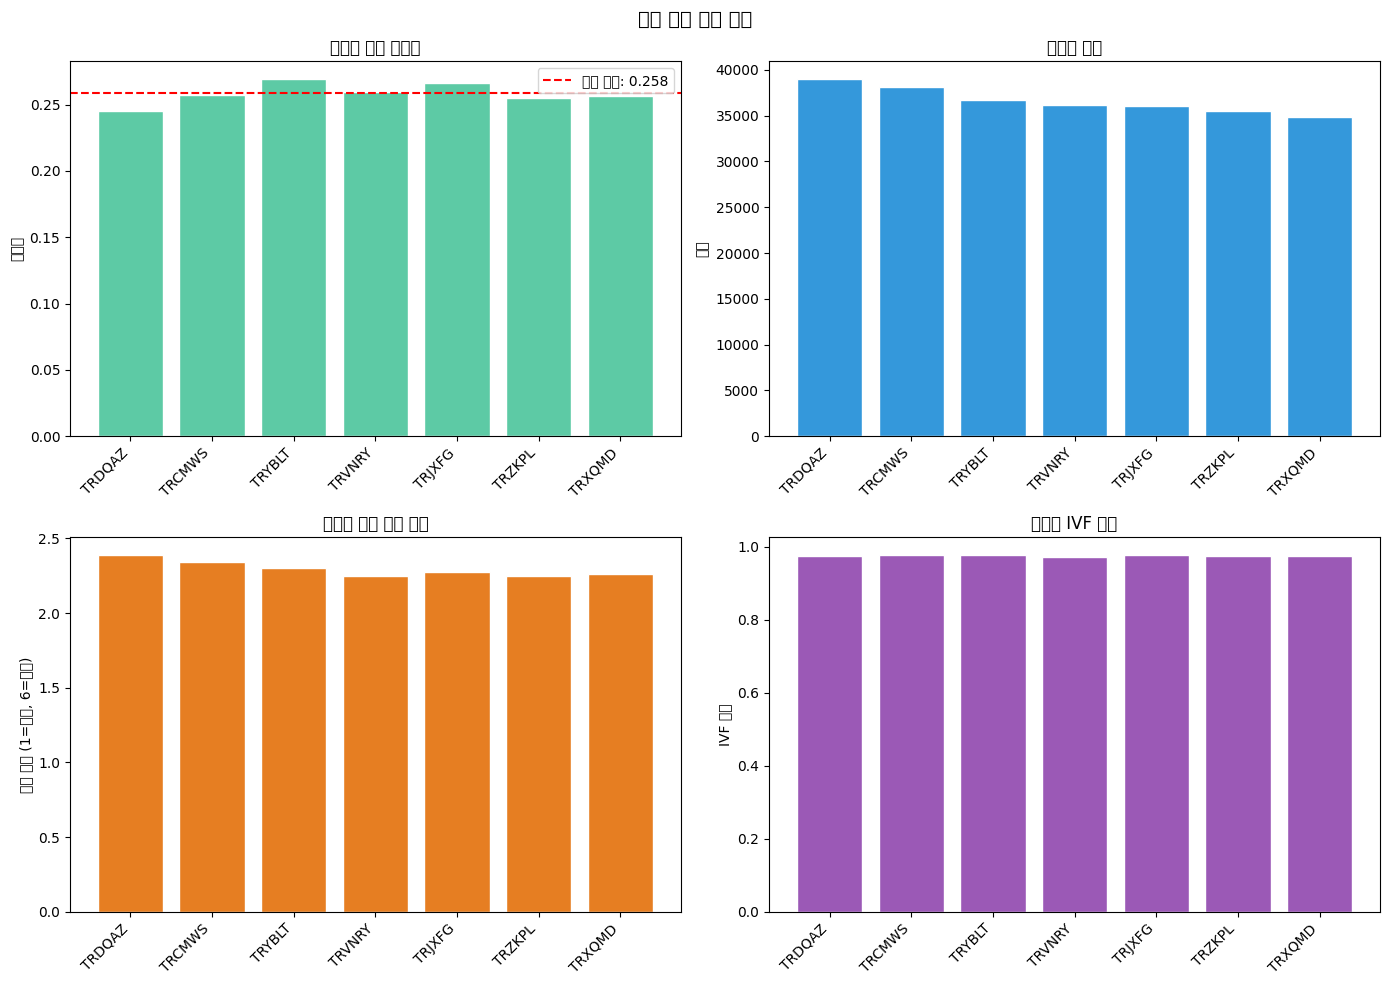

In [3]:
# 시간 순서 가설 검증
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

codes = code_stats.index.tolist()
x = range(len(codes))

# 성공률
axes[0,0].bar(x, code_stats['성공률'], color='#5DCAA5', edgecolor='white')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(codes, rotation=45, ha='right')
axes[0,0].set_title('코드별 임신 성공률')
axes[0,0].set_ylabel('성공률')
axes[0,0].axhline(train[TARGET].mean(), color='red', linestyle='--', label=f'전체 평균: {train[TARGET].mean():.3f}')
axes[0,0].legend()

# 건수
axes[0,1].bar(x, code_stats['건수'], color='#3498DB', edgecolor='white')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(codes, rotation=45, ha='right')
axes[0,1].set_title('코드별 건수')
axes[0,1].set_ylabel('건수')

# 평균 나이
axes[1,0].bar(x, code_stats['평균나이순서'], color='#E67E22', edgecolor='white')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(codes, rotation=45, ha='right')
axes[1,0].set_title('코드별 평균 나이 순서')
axes[1,0].set_ylabel('나이 순서 (1=젊음, 6=고령)')

# IVF 비율
axes[1,1].bar(x, code_stats['IVF비율'], color='#9B59B6', edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(codes, rotation=45, ha='right')
axes[1,1].set_title('코드별 IVF 비율')
axes[1,1].set_ylabel('IVF 비율')

plt.suptitle('시술 시기 코드 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# 코드 순서 가설 검증 - 알파벳 순서 vs 빈도 순서
# 알파벳 순서로 정렬 후 성공률 트렌드 확인
code_alpha = code_stats.sort_index()

print('=== 알파벳 순서로 정렬 ===')
display(code_alpha[['건수','성공률','평균나이순서']])

# 성공률과 알파벳 순서 상관관계
code_alpha['알파벳_순서'] = range(len(code_alpha))
corr_alpha = code_alpha[['알파벳_순서','성공률']].corr().iloc[0,1]
print(f'\n알파벳 순서 vs 성공률 상관계수: {corr_alpha:.4f}')

# 성공률 순서로 정렬
code_by_success = code_stats.sort_values('성공률', ascending=False)
print('\n=== 성공률 높은 순 ===')
display(code_by_success[['건수','성공률']])

=== 알파벳 순서로 정렬 ===


,건수,성공률,평균나이순서
시술 시기 코드,,,
TRCMWS,38090,0.2574,2.3403
TRDQAZ,38969,0.2454,2.3904
TRJXFG,36031,0.2663,2.2754
TRVNRY,36173,0.2598,2.2492
TRXQMD,34831,0.2561,2.2590
TRYBLT,36713,0.2691,2.2990
TRZKPL,35544,0.2551,2.2501



알파벳 순서 vs 성공률 상관계수: 0.2997

=== 성공률 높은 순 ===


,건수,성공률
시술 시기 코드,,
TRYBLT,36713,0.2691
TRJXFG,36031,0.2663
TRVNRY,36173,0.2598
TRCMWS,38090,0.2574
TRXQMD,34831,0.2561
TRZKPL,35544,0.2551
TRDQAZ,38969,0.2454


In [5]:
# Train / Test 코드 분포 비교
# train과 test의 코드 분포가 다르면 시간적 분할일 가능성
train_dist = train['시술 시기 코드'].value_counts(normalize=True).rename('train_%')
test_dist  = test['시술 시기 코드'].value_counts(normalize=True).rename('test_%')

dist_compare = pd.concat([train_dist, test_dist], axis=1).fillna(0).round(4)
dist_compare['차이'] = (dist_compare['train_%'] - dist_compare['test_%']).round(4)

print('=== Train / Test 코드 분포 비교 ===')
display(dist_compare.sort_values('차이', ascending=False))

# train에만 있고 test에 없는 코드 (또는 반대)
only_train = set(train['시술 시기 코드'].unique()) - set(test['시술 시기 코드'].unique())
only_test  = set(test['시술 시기 코드'].unique()) - set(train['시술 시기 코드'].unique())
print(f'\nTrain에만 있는 코드: {only_train}')
print(f'Test에만 있는 코드 : {only_test}')

=== Train / Test 코드 분포 비교 ===


,train_%,test_%,차이
시술 시기 코드,,,
TRXQMD,0.1359,0.1334,0.0025
TRVNRY,0.1411,0.1395,0.0016
TRDQAZ,0.1520,0.1511,0.0009
TRCMWS,0.1486,0.1487,-0.0001
TRYBLT,0.1432,0.1435,-0.0003
TRJXFG,0.1406,0.1417,-0.0011
TRZKPL,0.1387,0.1420,-0.0033



Train에만 있는 코드: set()
Test에만 있는 코드 : set()


In [6]:
# 종합 판단 및 추가 피처 설계
print('=== 종합 분석 결과 ===')
print()
print(f'코드 수: {train["시술 시기 코드"].nunique()}개')
print(f'성공률 범위: {code_stats["성공률"].min():.4f} ~ {code_stats["성공률"].max():.4f}')
print(f'성공률 편차: {code_stats["성공률"].std():.4f}')
print(f'알파벳-성공률 상관: {corr_alpha:.4f}')
print()

# 성공률 편차가 크면 코드가 의미 있는 정보
if code_stats['성공률'].std() > 0.02:
    print('✅ 코드별 성공률 편차가 큼 → 시술 시기 코드가 유의미한 정보')
else:
    print('⚠️ 코드별 성공률 편차가 작음 → 코드가 랜덤 또는 의미 없을 수 있음')

if abs(corr_alpha) > 0.3:
    print('✅ 알파벳 순서와 성공률 상관관계 있음 → 시간 순서 가능성 높음')
else:
    print('⚠️ 알파벳 순서와 성공률 무관 → 시간 순서 아닐 가능성')

if only_train or only_test:
    print(f'✅ Train/Test 코드 분포 다름 → 시간적 분할 가능성 있음')
else:
    print('⚠️ Train/Test 코드 분포 동일 → 랜덤 분할일 가능성')

=== 종합 분석 결과 ===

코드 수: 7개
성공률 범위: 0.2454 ~ 0.2691
성공률 편차: 0.0078
알파벳-성공률 상관: 0.2997

⚠️ 코드별 성공률 편차가 작음 → 코드가 랜덤 또는 의미 없을 수 있음
⚠️ 알파벳 순서와 성공률 무관 → 시간 순서 아닐 가능성
⚠️ Train/Test 코드 분포 동일 → 랜덤 분할일 가능성


In [8]:
# 성공률 기반 코드 인코딩 (OOF Target Encoding과 다름 — 전체 train 통계)
# 이미 feature_importance_analysis에서 빈도 기반 순서형을 만들었으므로
# 여기서는 성공률 기반 순서형 추가

# 성공률 기반 순서 (높을수록 1번)
success_order = (
    code_stats['성공률']
    .rank(ascending=False, method='first')
    .astype(int)
    .to_dict()
)

for df in [train, test]:
    df['시술시기_성공률순서'] = df['시술 시기 코드'].map(success_order).fillna(-1).astype(int)

print('성공률 기반 순서형 인코딩 완료')
print()
mapping_df = pd.DataFrame({
    '코드': list(success_order.keys()),
    '성공률순서': list(success_order.values()),
    '성공률': [code_stats.loc[k, '성공률'] for k in success_order.keys()]
}).sort_values('성공률순서')
display(mapping_df)

# 빈도 기반 순서형은 이 노트북에 없으므로 생략
# 성공률 순서형 단독으로 확인
print(f'\n시술시기_성공률순서 분포:')
print(train['시술시기_성공률순서'].value_counts().sort_index())

성공률 기반 순서형 인코딩 완료



,코드,성공률순서,성공률
2,TRYBLT,1,0.2691
4,TRJXFG,2,0.2663
3,TRVNRY,3,0.2598
1,TRCMWS,4,0.2574
6,TRXQMD,5,0.2561
5,TRZKPL,6,0.2551
0,TRDQAZ,7,0.2454



시술시기_성공률순서 분포:
시술시기_성공률순서
1    36713
2    36031
3    36173
4    38090
5    34831
6    35544
7    38969
Name: count, dtype: int64
